In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from xgboost import cv
import os 
import seaborn as sns

In [3]:
path = os.path.join("..","data","hotel_bookings.csv")
df = pd.read_csv(path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
df.duplicated().sum()

np.int64(31994)

In [6]:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [7]:
df.groupby("arrival_date_day_of_month")["is_canceled"].describe()

,count,mean,std,min,25%,50%,75%,max
arrival_date_day_of_month,,,,,,,,
1,3626.0,0.398235,0.489602,0.0,0.0,0.0,1.0,1.0
2,4055.0,0.341554,0.474289,0.0,0.0,0.0,1.0,1.0
3,3855.0,0.400778,0.490120,0.0,0.0,0.0,1.0,1.0
4,3763.0,0.359022,0.479777,0.0,0.0,0.0,1.0,1.0
5,4317.0,0.388927,0.487563,0.0,0.0,0.0,1.0,1.0
6,3833.0,0.333159,0.471404,0.0,0.0,0.0,1.0,1.0
7,3665.0,0.393179,0.488523,0.0,0.0,0.0,1.0,1.0
8,3921.0,0.420046,0.493629,0.0,0.0,0.0,1.0,1.0
9,4096.0,0.378418,0.485052,0.0,0.0,0.0,1.0,1.0


In [8]:
categorical_columns= [
    "hotel","arrival_date_year","arrival_date_month","arrival_date_day_of_month","meal","distribution_channel"
    ,"market_segment","country","reserved_room_type","deposit_type","agent","customer_type","arrival_day_period"
]
numerical_columns = [
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "is_repeated_guest",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_guests"
]
leaks = ["reservation_status", "reservation_status_date","assigned_room_type"]

drops = ["arrival_date_week_number","previous_bookings_not_canceled","assigned_room_type","company"]


<Axes: xlabel='stays_in_weekend_nights', ylabel='count'>

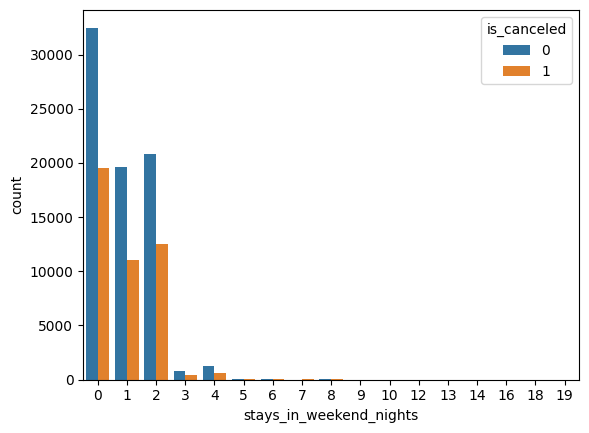

In [9]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df.stays_in_weekend_nights,
    hue = df.is_canceled
)

<Axes: xlabel='stays_in_week_nights', ylabel='count'>

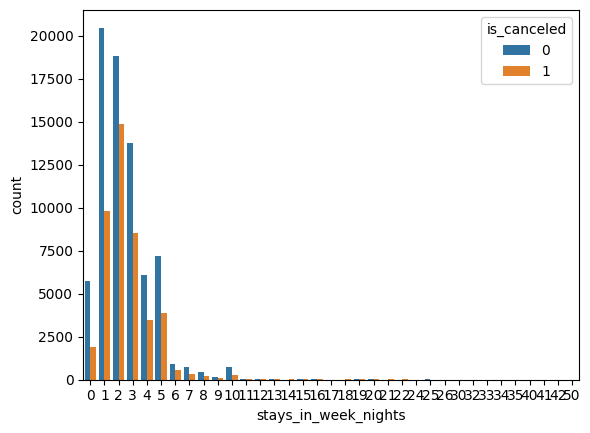

In [10]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["stays_in_week_nights"],
    hue = df.is_canceled
)

<Axes: xlabel='adults', ylabel='count'>

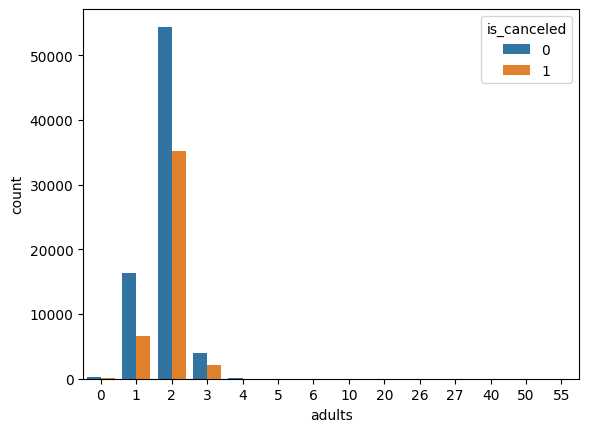

In [11]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["adults"],
    hue = df.is_canceled
)

<Axes: xlabel='babies', ylabel='count'>

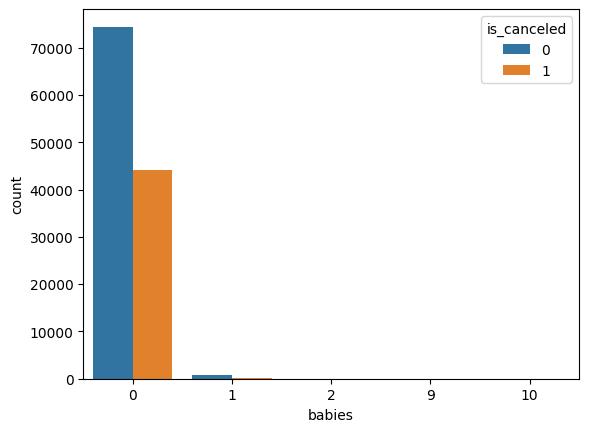

In [12]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["babies"],
    hue = df.is_canceled
)

<Axes: xlabel='is_repeated_guest', ylabel='count'>

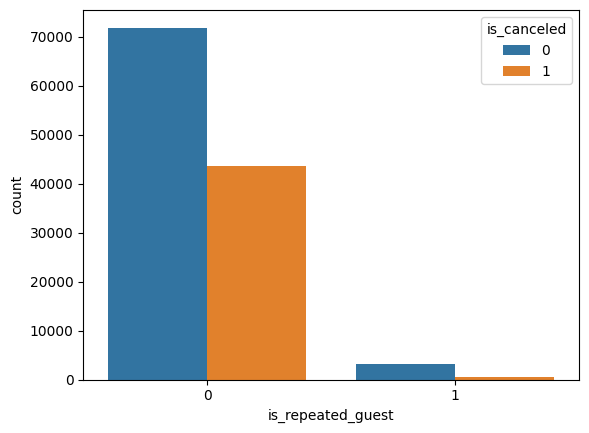

In [13]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["is_repeated_guest"],
    hue = df.is_canceled
)

<Axes: xlabel='previous_cancellations', ylabel='count'>

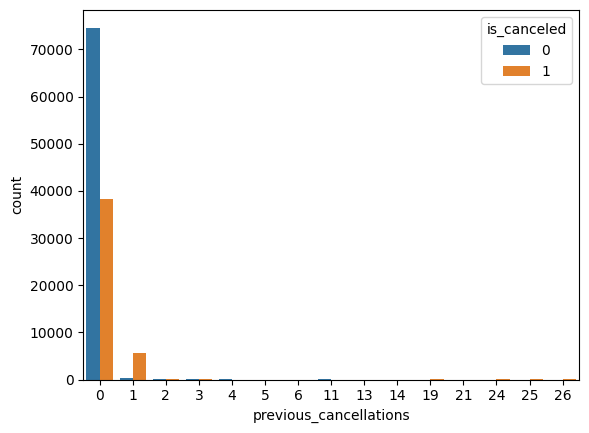

In [14]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["previous_cancellations"],
    hue = df.is_canceled
)

In [15]:
df.groupby("reserved_room_type")["is_canceled"].describe()

,count,mean,std,min,25%,50%,75%,max
reserved_room_type,,,,,,,,
A,85994.0,0.391074,0.487994,0.0,0.0,0.0,1.00,1.0
B,1118.0,0.329159,0.470118,0.0,0.0,0.0,1.00,1.0
C,932.0,0.330472,0.470636,0.0,0.0,0.0,1.00,1.0
D,19201.0,0.317796,0.465632,0.0,0.0,0.0,1.00,1.0
E,6535.0,0.292884,0.455121,0.0,0.0,0.0,1.00,1.0
F,2897.0,0.303763,0.459961,0.0,0.0,0.0,1.00,1.0
G,2094.0,0.364374,0.481369,0.0,0.0,0.0,1.00,1.0
H,601.0,0.407654,0.491808,0.0,0.0,0.0,1.00,1.0
L,6.0,0.333333,0.516398,0.0,0.0,0.0,0.75,1.0


In [16]:
df.groupby("assigned_room_type")["is_canceled"].describe()

,count,mean,std,min,25%,50%,75%,max
assigned_room_type,,,,,,,,
A,74053.0,0.444925,0.496961,0.0,0.0,0.0,1.0,1.0
B,2163.0,0.236708,0.425160,0.0,0.0,0.0,0.0,1.0
C,2375.0,0.187789,0.390626,0.0,0.0,0.0,0.0,1.0
D,25322.0,0.251244,0.433737,0.0,0.0,0.0,1.0,1.0
E,7806.0,0.252114,0.434254,0.0,0.0,0.0,1.0,1.0
F,3751.0,0.247134,0.431403,0.0,0.0,0.0,0.0,1.0
G,2553.0,0.305523,0.460719,0.0,0.0,0.0,1.0,1.0
H,712.0,0.352528,0.478093,0.0,0.0,0.0,1.0,1.0
I,363.0,0.013774,0.116713,0.0,0.0,0.0,0.0,1.0


In [17]:
df["get_the_room"] = df["assigned_room_type"] == df["reserved_room_type"]

<Axes: xlabel='get_the_room', ylabel='count'>

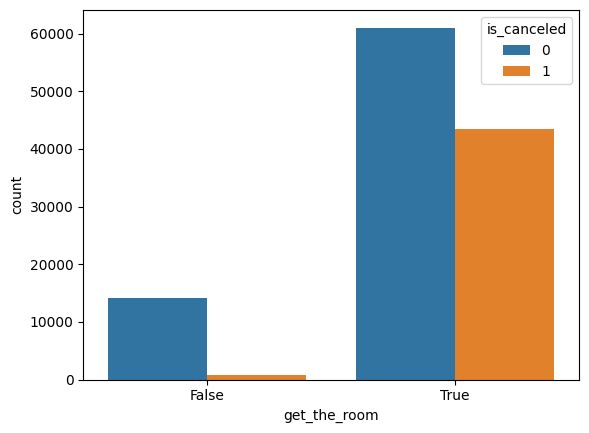

In [18]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["get_the_room"],
    hue = df.is_canceled
)

<Axes: xlabel='booking_changes', ylabel='count'>

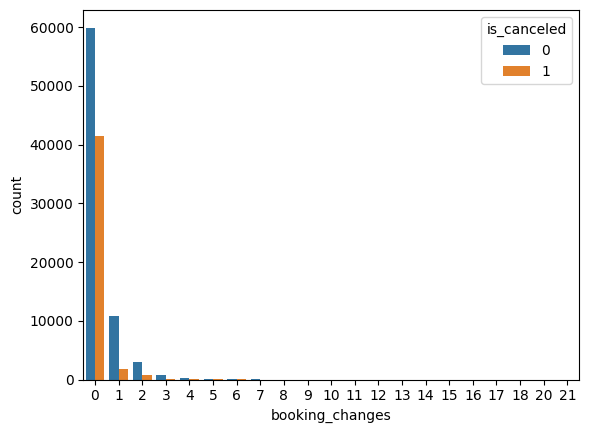

In [19]:
import seaborn as sns 
sns.countplot(
    data = df,
    x  = df["booking_changes"],
    hue = df.is_canceled
)

In [20]:
df.groupby("deposit_type")["is_canceled"].describe()

,count,mean,std,min,25%,50%,75%,max
deposit_type,,,,,,,,
No Deposit,104641.0,0.283770,0.450829,0.0,0.0,0.0,1.0,1.0
Non Refund,14587.0,0.993624,0.079595,0.0,1.0,1.0,1.0,1.0
Refundable,162.0,0.222222,0.417029,0.0,0.0,0.0,0.0,1.0


In [21]:
df[df["deposit_type"] == "Non Refund"].describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.0,14587.000000,14587.000000,14587.000000,14587.000000,12536.000000,506.000000,14587.000000,14587.000000,14587.000000,14587.000000
mean,0.993624,212.908891,2016.031466,27.448619,15.595462,0.621718,2.091109,1.811407,0.000617,0.0,0.004387,0.411462,0.010626,0.012477,55.248165,179.189723,7.992253,89.964017,0.000069,0.001782
std,0.079595,133.324402,0.730267,13.331718,8.699557,0.819541,1.152321,0.393992,0.032062,0.0,0.066095,1.992486,0.443376,0.125499,89.745282,119.135598,29.496511,53.389570,0.008280,0.045317
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,20.000000,0.000000,6.000000,0.000000,0.000000
25%,1.000000,103.000000,2015.000000,17.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,67.000000,0.000000,62.800000,0.000000,0.000000
50%,1.000000,183.000000,2016.000000,25.000000,16.000000,0.000000,2.000000,2.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,19.000000,197.000000,0.000000,86.000000,0.000000,0.000000
75%,1.000000,304.000000,2017.000000,39.000000,23.000000,1.000000,3.000000,2.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,56.000000,223.000000,0.000000,110.000000,0.000000,0.000000
max,1.000000,629.000000,2017.000000,53.000000,31.000000,7.000000,16.000000,3.000000,2.000000,0.0,1.000000,26.000000,29.000000,4.000000,495.000000,504.000000,391.000000,5400.000000,1.000000,2.000000


<Axes: xlabel='days_in_waiting_list', ylabel='count'>

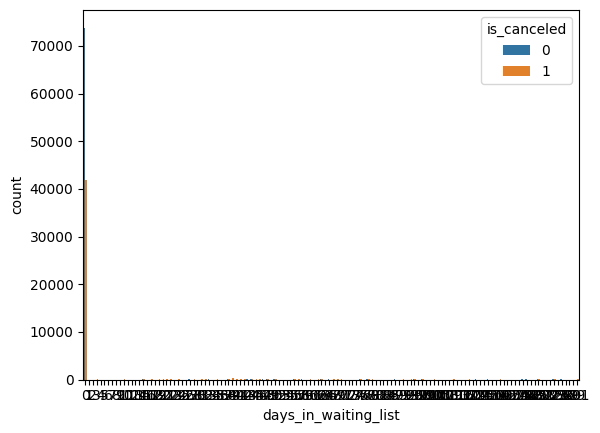

In [22]:

sns.countplot(
    data=df,
    x="days_in_waiting_list",
    hue="is_canceled"
)

{'whiskers': [<matplotlib.lines.Line2D at 0x253b0a85e80>,
 'caps': [<matplotlib.lines.Line2D at 0x253b0a86120>,
 'boxes': [<matplotlib.lines.Line2D at 0x253b0a85d30>],
 'medians': [<matplotlib.lines.Line2D at 0x253b0a863c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x253b0a86510>],
 'means': []}

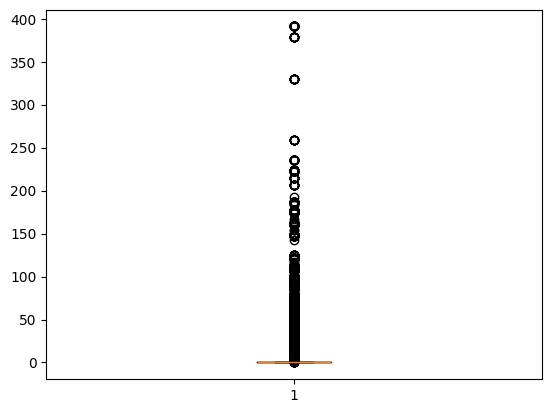

In [23]:
plt.boxplot(df["days_in_waiting_list"])

In [24]:
df.groupby("customer_type")["is_canceled"].describe()

,count,mean,std,min,25%,50%,75%,max
customer_type,,,,,,,,
Contract,4076.0,0.309617,0.462393,0.0,0.0,0.0,1.0,1.0
Group,577.0,0.102253,0.303244,0.0,0.0,0.0,0.0,1.0
Transient,89613.0,0.407463,0.491365,0.0,0.0,0.0,1.0,1.0
Transient-Party,25124.0,0.254299,0.435475,0.0,0.0,0.0,1.0,1.0


<Axes: xlabel='adr', ylabel='Count'>

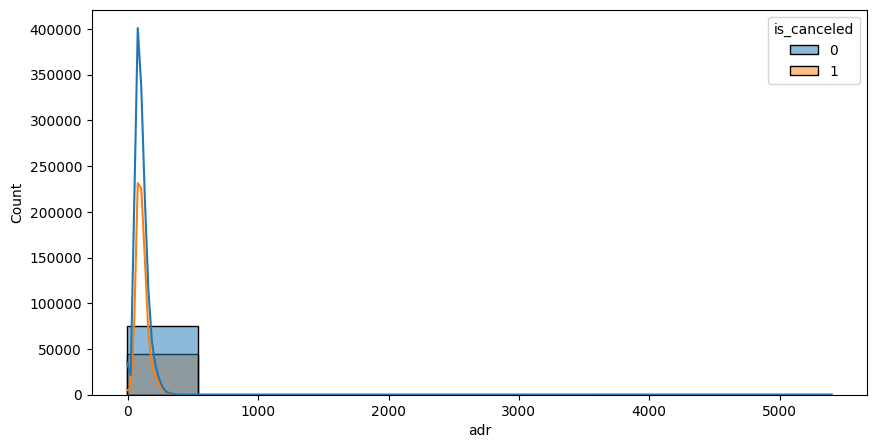

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="adr",
    hue="is_canceled",
    bins=10,
    kde=True
)

<Axes: xlabel='total_of_special_requests', ylabel='Count'>

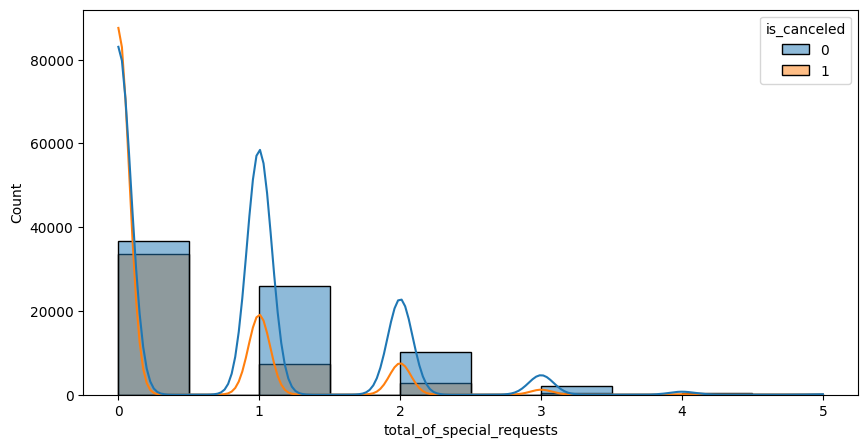

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="total_of_special_requests",
    hue="is_canceled",
    bins=10,
    kde=True
)

In [27]:
explore_df = df.copy()

explore_df["room_type_match"] = (
    explore_df["assigned_room_type"] ==
    explore_df["reserved_room_type"]
)

pd.crosstab(
    explore_df["room_type_match"],
    explore_df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
room_type_match,,
False,0.946236,0.053764
True,0.584371,0.415629
